# Carbon budget outcome across the 12 scenarios

Four charts in two figures. Cumulative emissions over time, and the 2050 total as bars, each
shown for smelting alone and for smelting plus refining. The 1.5°C sector budget is on all four.

Self contained: everything is in these cells, nothing imported from `common.py`.

In [12]:
import glob
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RUNS = Path("../../runs")
ARCHIVE = Path("../../../_archive/scenarios_92switches")
MODEL = Path("../../models/model_clean/aluminium/data/lc")

# rows of the 3 x 4 matrix, used here as the line style / bar grouping
CAPTURES = [("noCCS", "No CCS", ":"),
            ("limitedCCS", "Limited CCS", "--"),
            ("CCS", "Unlimited CCS", "-")]

# columns of the matrix, used here as the colour
COLUMNS = [("MPP",  "Locked",   "MPP grid, inert anode locked",    "#9b2226"),
           ("SBTi", "Locked",   "SBTi grid, inert anode locked",   "#b45309"),
           ("MPP",  "Unlocked", "MPP grid, inert anode unlocked",  "#003f88"),
           ("SBTi", "Unlocked", "SBTi grid, inert anode unlocked", "#386641")]

plt.rcParams.update({"font.family": "sans-serif", "axes.spines.top": False,
                     "axes.spines.right": False})

## Load emissions and the budgets

In [13]:
def emissions(capture, grid, anode, plant):
    """Scope 1 plus scope 2 by year, Mt CO2."""
    name = f"LC_{grid}grid_{capture}_Anode{anode}"
    folder = ARCHIVE if capture == "noCCS" else RUNS
    path = glob.glob(str(folder / name / plant / "final" / "interface_outputs_*.csv"))[0]
    df = pd.read_csv(path)
    df = df[df["technology"] != "All"]
    scope1 = df[df["parameter"] == "CO2 Scope1"].groupby("year")["value"].sum()
    scope2 = df[df["parameter"] == "CO2 Scope2"].groupby("year")["value"].sum()
    return (scope1 + scope2).loc[2020:2050]


def budget(folder):
    """MPP's annual carbon budget, Mt CO2."""
    series = pd.read_csv(MODEL / folder / "intermediate" / "carbon_budget.csv")
    return (series.set_index("year")["annual_limit"] * 1000).loc[2020:2050]


smelting = {(c, g, a): emissions(c, g, a, "smelter")
            for c, _, _ in CAPTURES for g, a, _, _ in COLUMNS}
refining = {(c, g, a): emissions(c, g, a, "refinery")
            for c, _, _ in CAPTURES for g, a, _, _ in COLUMNS}
combined = {k: smelting[k] + refining[k] for k in smelting}

budget_smelting = budget("def")
budget_combined = budget("def") + budget("def_refineries")

# cumulative, in Gt
cum_smelting = {k: v.cumsum() / 1000 for k, v in smelting.items()}
cum_combined = {k: v.cumsum() / 1000 for k, v in combined.items()}
cum_budget_smelting = budget_smelting.cumsum() / 1000
cum_budget_combined = budget_combined.cumsum() / 1000

print(f"smelting budget {cum_budget_smelting.loc[2050]:.2f} Gt, "
      f"combined budget {cum_budget_combined.loc[2050]:.2f} Gt")

smelting budget 10.16 Gt, combined budget 11.99 Gt


## Figure 1: cumulative emissions over time

Colour is the grid and inert anode combination, line style is the capture regime.

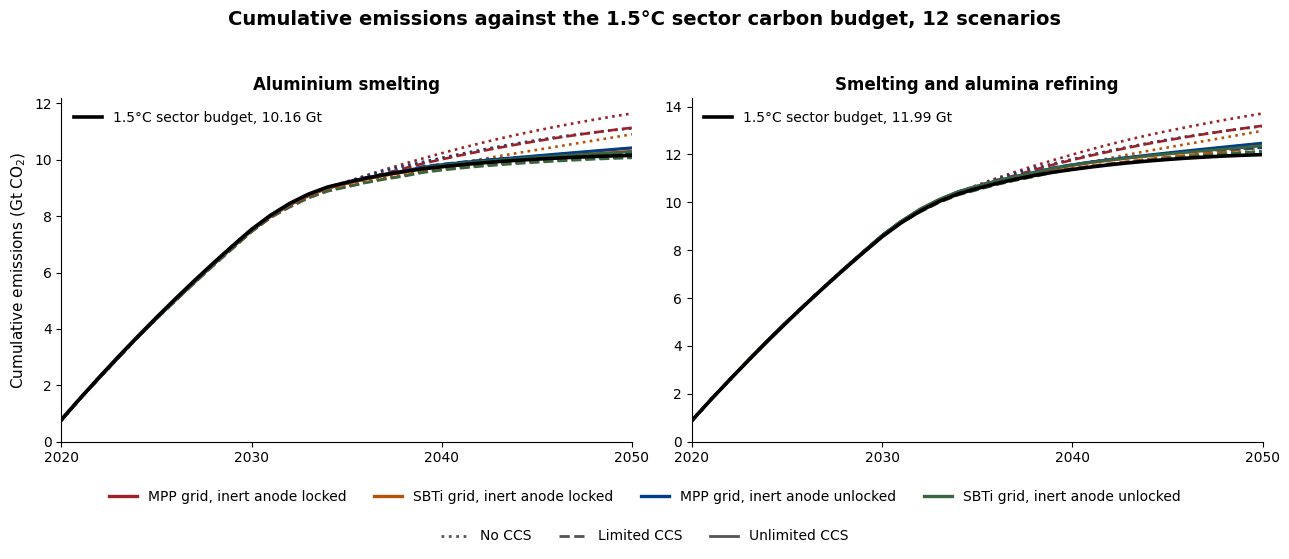

In [14]:
PANELS = [("Aluminium smelting", cum_smelting, cum_budget_smelting),
          ("Smelting and alumina refining", cum_combined, cum_budget_combined)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), sharex=True)

for ax, (panel_title, series, budget_line) in zip(axes, PANELS):
    for capture, capture_label, style in CAPTURES:
        for grid, anode, column_label, colour in COLUMNS:
            line = series[(capture, grid, anode)]
            ax.plot(line.index, line.values, color=colour, linestyle=style, linewidth=1.9)
    ax.plot(budget_line.index, budget_line.values, color="black", linewidth=2.6,
            label=f"1.5\u00b0C sector budget, {budget_line.loc[2050]:.2f} Gt")
    ax.set_title(panel_title, fontsize=12, fontweight="bold")
    ax.set_xlim(2020, 2050); ax.set_xticks(range(2020, 2051, 10))
    ax.set_ylim(bottom=0)
    ax.legend(loc="upper left", fontsize=10, frameon=False)

axes[0].set_ylabel("Cumulative emissions (Gt CO$_2$)", fontsize=11)

# two-part legend: colour for the column, line style for the capture regime
colour_keys = [plt.Line2D([], [], color=c, lw=2.4, label=l) for _, _, l, c in COLUMNS]
style_keys = [plt.Line2D([], [], color="#555555", lw=2.0, linestyle=s, label=l)
              for _, l, s in CAPTURES]
fig.legend(handles=colour_keys, loc="lower center", ncol=4, frameon=False, fontsize=10,
           bbox_to_anchor=(0.5, 0.075))
fig.legend(handles=style_keys, loc="lower center", ncol=3, frameon=False, fontsize=10,
           bbox_to_anchor=(0.5, 0.005))

fig.suptitle("Cumulative emissions against the 1.5\u00b0C sector carbon budget, 12 scenarios",
             fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0.14, 1, 0.95])
for extension in ("png", "svg"):
    fig.savefig(f"../../figures/budget_cumulative_over_time.{extension}", dpi=200,
                bbox_inches="tight")
plt.show()

## Figure 2: the 2050 total as bars

Twelve bars per panel, grouped by capture regime. The vertical line is the budget.

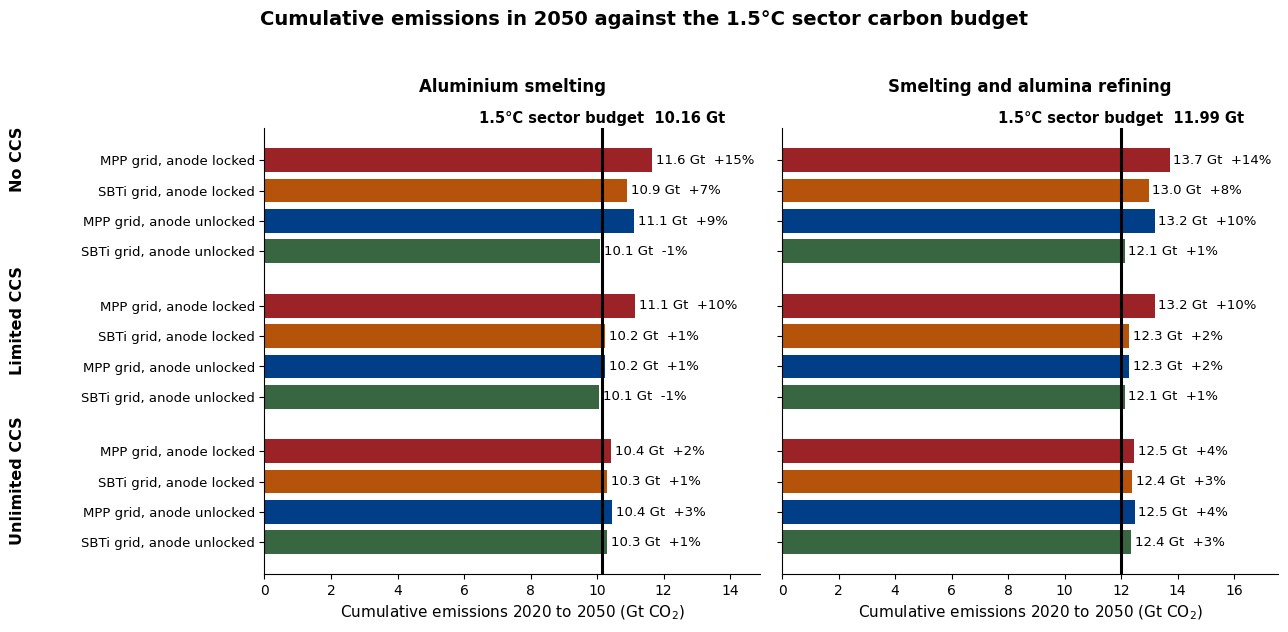

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6.4), sharey=True)

for ax, (panel_title, series, budget_line) in zip(axes, PANELS):
    total_budget = budget_line.loc[2050]
    labels, values, colours, positions = [], [], [], []
    y = 0.0
    for capture, capture_label, _ in CAPTURES:
        for grid, anode, column_label, colour in COLUMNS:
            labels.append(column_label.replace("inert anode ", "anode "))
            values.append(series[(capture, grid, anode)].loc[2050])
            colours.append(colour)
            positions.append(y)
            y += 1
        y += 0.8                                    # gap between capture regimes

    bars = ax.barh(positions, values, color=colours, height=0.78)
    ax.axvline(total_budget, color="black", linewidth=2.2)
    ax.text(total_budget, -1.15, f"1.5\u00b0C sector budget  {total_budget:.2f} Gt",
            ha="center", va="bottom", fontsize=10.5, fontweight="bold")

    for bar, value in zip(bars, values):
        over = 100 * (value / total_budget - 1)
        ax.text(value + 0.12, bar.get_y() + bar.get_height() / 2,
                f"{value:.1f} Gt  {over:+.0f}%", va="center", fontsize=9.5)

    ax.set_yticks(positions)
    ax.set_yticklabels(labels, fontsize=9.5)
    ax.set_xlabel("Cumulative emissions 2020 to 2050 (Gt CO$_2$)", fontsize=11)
    ax.set_xlim(0, max(values) * 1.28)
    ax.set_title(panel_title, fontsize=12, fontweight="bold", pad=26)

axes[0].invert_yaxis()          # shared y, so invert once or it flips back

# capture regime name at the far left, in figure coordinates so it clears the tick labels
fig.canvas.draw()
for row, (capture, capture_label, _) in enumerate(CAPTURES):
    centre_data = row * 4 + 1.5 + row * 0.8
    _, y_display = axes[0].transData.transform((0, centre_data))
    _, y_figure = fig.transFigure.inverted().transform((0, y_display))
    fig.text(0.012, y_figure, capture_label, rotation=90,
             ha="left", va="center", fontsize=11.5, fontweight="bold")

fig.suptitle("Cumulative emissions in 2050 against the 1.5\u00b0C sector carbon budget",
             fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0.055, 0, 1, 0.95])
for extension in ("png", "svg"):
    fig.savefig(f"../../figures/budget_total_bars.{extension}", dpi=200, bbox_inches="tight")
plt.show()

## The numbers

In [25]:
# Row 0 is business as usual, rows 1 to 12 are the scenarios, numbered as in the figures.
def bau_cumulative(plant):
    """Cumulative BAU emissions to 2050, Gt CO2. BAU has its own folder name."""
    path = glob.glob(str(RUNS / "BAU" / plant / "final" / "interface_outputs_*.csv"))[0]
    df = pd.read_csv(path)
    df = df[df["technology"] != "All"]
    scope1 = df[df["parameter"] == "CO2 Scope1"].groupby("year")["value"].sum()
    scope2 = df[df["parameter"] == "CO2 Scope2"].groupby("year")["value"].sum()
    return (scope1 + scope2).loc[2020:2050].sum() / 1000


bau_smelting = bau_cumulative("smelter")
bau_combined = bau_smelting + bau_cumulative("refinery")

rows = [{"Capture regime": "Business as usual",
         "Grid and anode": "MPP grid, no carbon budget applied",
         "Smelting emissions (Gt CO2)": bau_smelting,
         "Share of smelting budget (%)": 100 * bau_smelting / cum_budget_smelting.loc[2050],
         "Smelting and refining emissions (Gt CO2)": bau_combined,
         "Share of sector budget (%)": 100 * bau_combined / cum_budget_combined.loc[2050]}]

for capture, capture_label, _ in CAPTURES:
    for grid, anode, column_label, _ in COLUMNS:
        s = cum_smelting[(capture, grid, anode)].loc[2050]
        c = cum_combined[(capture, grid, anode)].loc[2050]
        rows.append({"Capture regime": capture_label,
                     "Grid and anode": column_label,
                     "Smelting emissions (Gt CO2)": s,
                     "Share of smelting budget (%)": 100 * s / cum_budget_smelting.loc[2050],
                     "Smelting and refining emissions (Gt CO2)": c,
                     "Share of sector budget (%)": 100 * c / cum_budget_combined.loc[2050]})

pd.DataFrame(rows).round(1)

,Capture regime,Grid and anode,Smelting emissions (Gt CO2),Share of smelting budget (%),Smelting and refining emissions (Gt CO2),Share of sector budget (%)
0,Business as usual,"MPP grid, no carbon budget applied",27.4,269.7,31.1,259.5
1,No CCS,"MPP grid, inert anode locked",11.6,114.6,13.7,114.3
2,No CCS,"SBTi grid, inert anode locked",10.9,107.4,13.0,108.3
3,No CCS,"MPP grid, inert anode unlocked",11.1,109.5,13.2,109.9
4,No CCS,"SBTi grid, inert anode unlocked",10.1,99.4,12.1,101.2
5,Limited CCS,"MPP grid, inert anode locked",11.1,109.6,13.2,110.0
6,Limited CCS,"SBTi grid, inert anode locked",10.2,100.9,12.3,102.4
7,Limited CCS,"MPP grid, inert anode unlocked",10.2,100.8,12.3,102.4
8,Limited CCS,"SBTi grid, inert anode unlocked",10.1,99.1,12.1,101.1
9,Unlimited CCS,"MPP grid, inert anode locked",10.4,102.5,12.5,103.9
